# ДЗ 2. Customer Churn

Чи піде клієнт протягом 30 днів після `prediction_ts`. Дані тестові.

In [1]:
import sys, subprocess, warnings
from pathlib import Path

warnings.filterwarnings("ignore")

# pgserver ставиться лише на Python <= 3.12, у Colab зараз 3.13 — тоді беру його форк
pkg = "pgserver" if sys.version_info < (3, 13) else "pixeltable-pgserver"
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "--disable-pip-version-check",
                       pkg, "jupysql", "psycopg2-binary"])

pgdata = Path("/content/pgdata" if Path("/content").exists() else "pgdata").resolve()
if pkg == "pgserver":
    import pgserver
    server = pgserver.get_server(pgdata)
else:
    import pixeltable_pgserver
    server = pixeltable_pgserver.get_server(pgdata, postgres_version=16)

print(server.psql("SHOW server_version;"))

 server_version 
----------------
 16.14
(1 row)




In [2]:
import sqlalchemy as sa

engine = sa.create_engine(server.get_uri().replace("postgresql://", "postgresql+psycopg2://", 1))
%load_ext sql
%config SqlMagic.displaycon = False
%sql engine

## 1. ER-діаграма

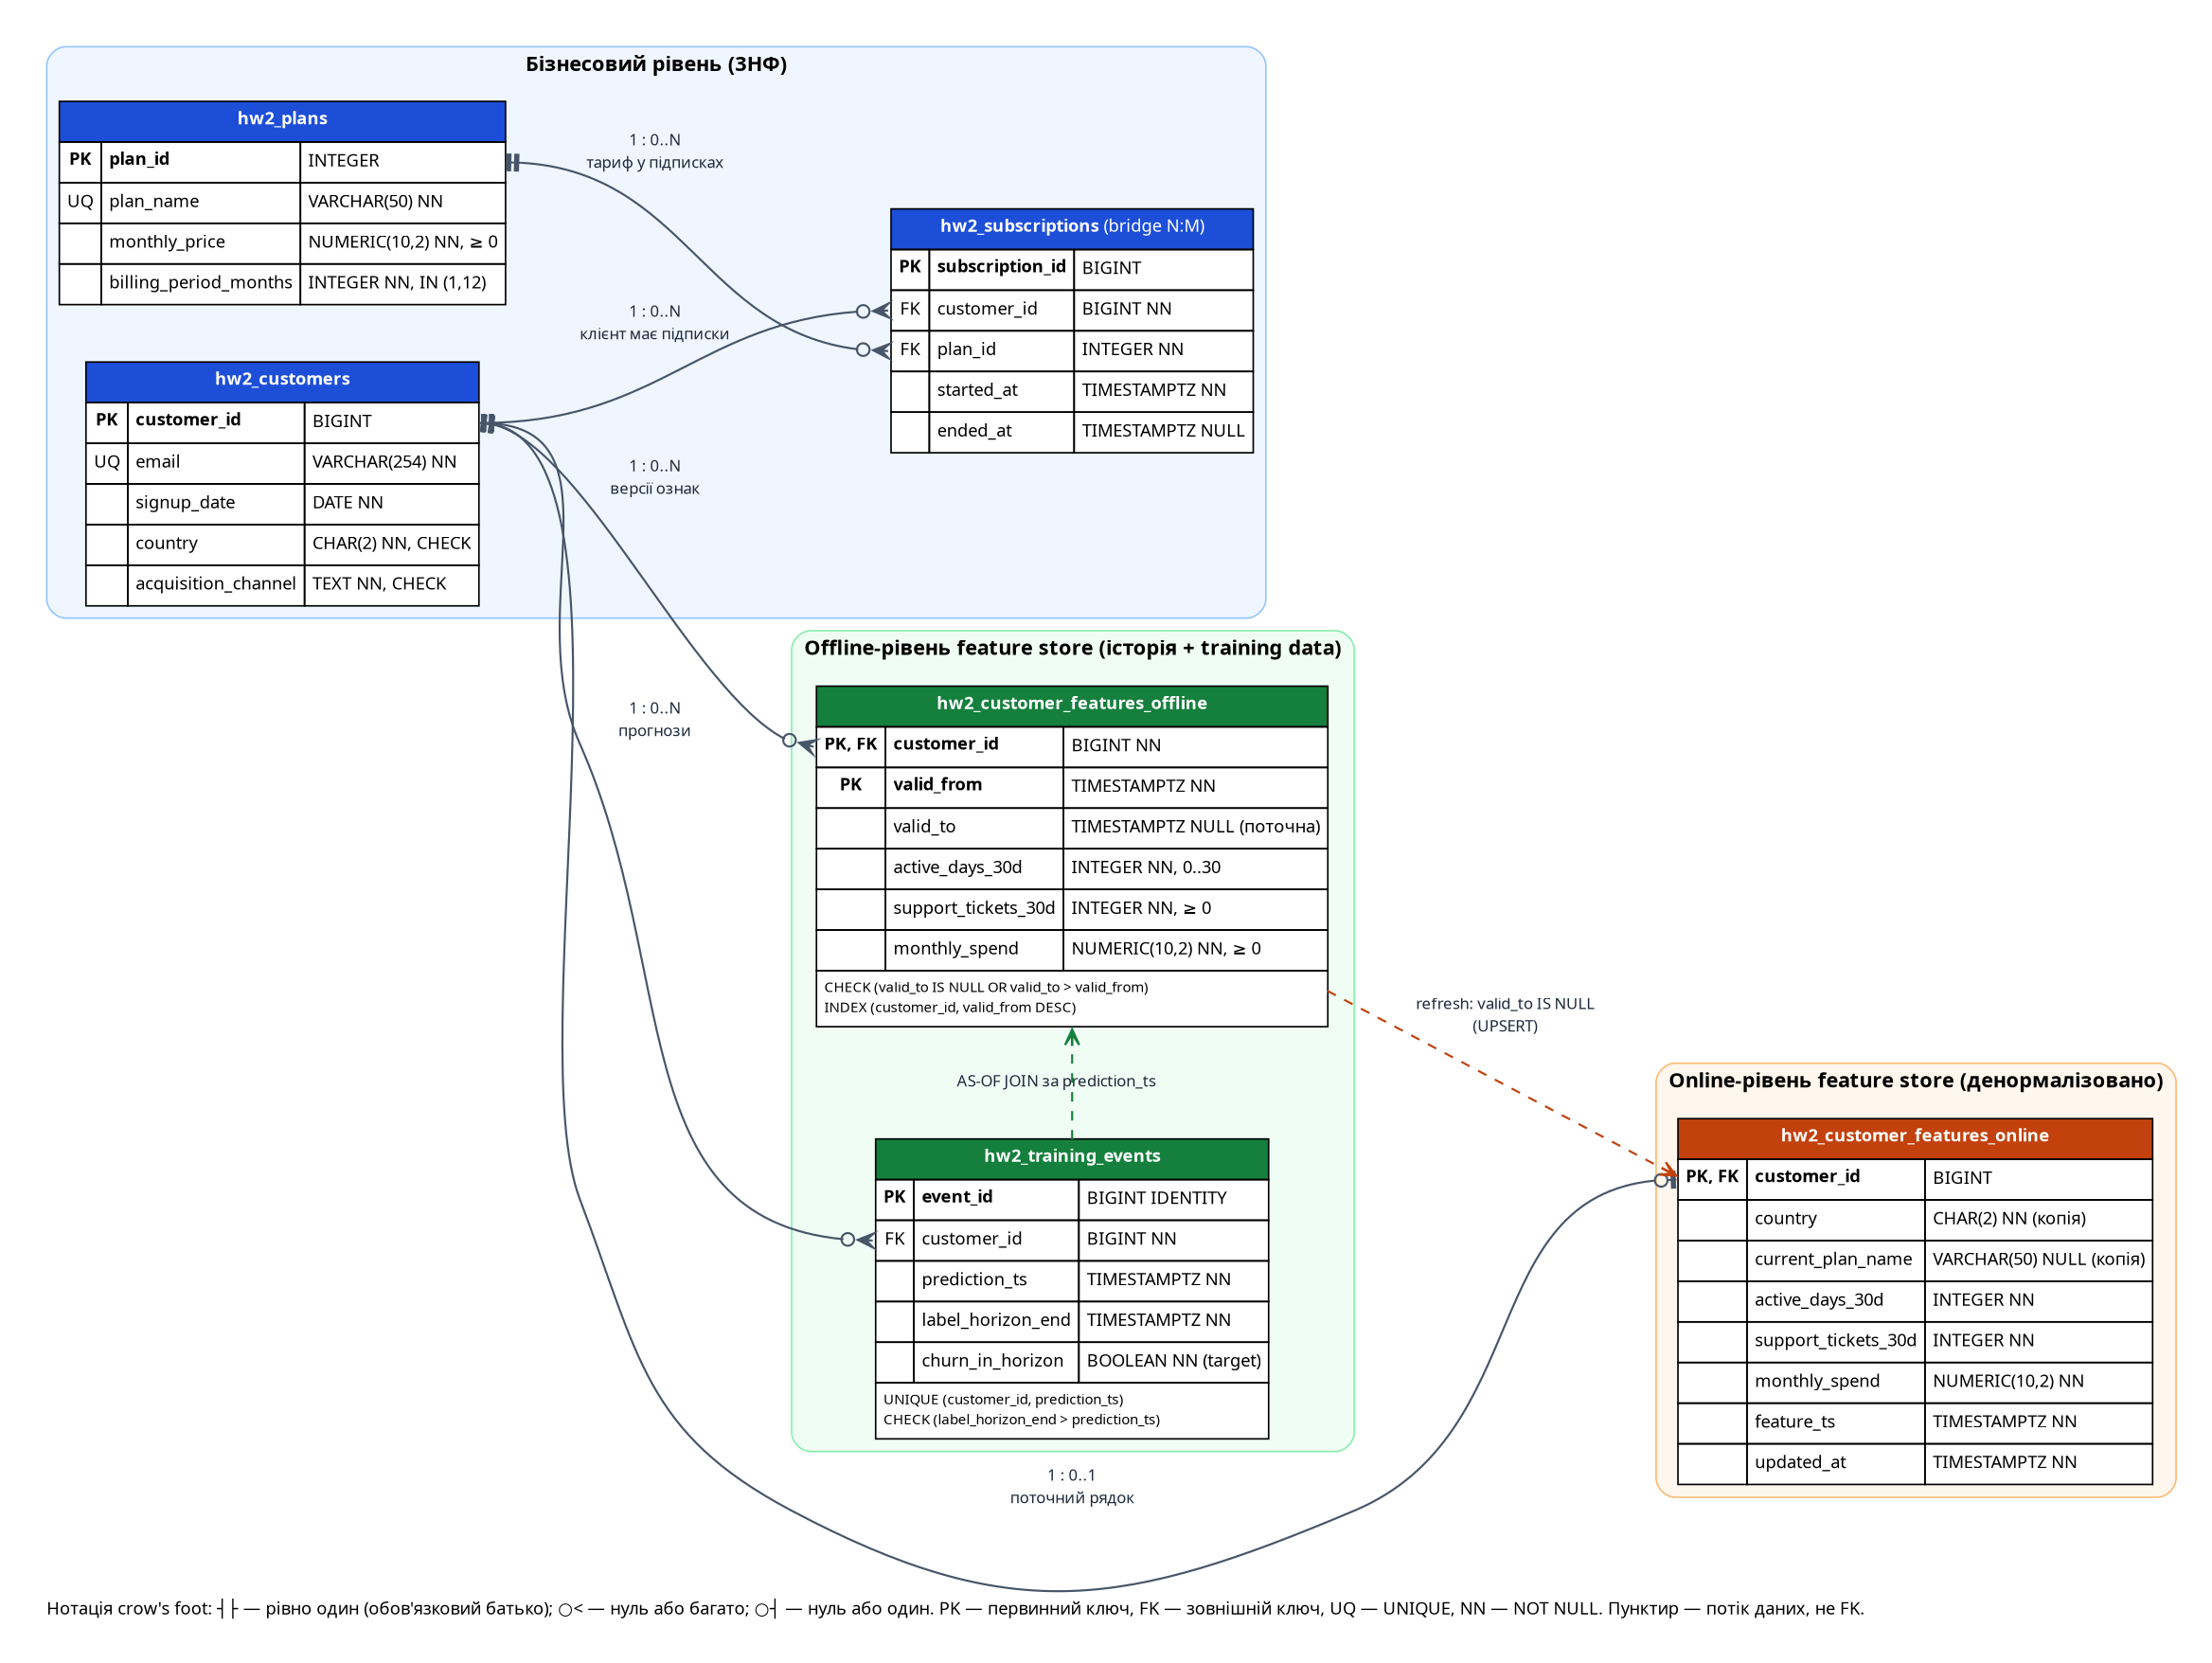

Клієнт може з часом змінювати тарифи, тому `customers ↔ plans` — це N:M через `hw2_subscriptions`.

## 2. DDL

In [3]:
%%sql
SET TIME ZONE 'UTC';

DROP TABLE IF EXISTS
    hw2_customer_features_online,
    hw2_training_events,
    hw2_customer_features_offline,
    hw2_subscriptions,
    hw2_plans,
    hw2_customers
CASCADE;

++
||
++
++

In [4]:
%%sql
CREATE TABLE hw2_customers (
    customer_id         BIGINT PRIMARY KEY,
    email               VARCHAR(254) NOT NULL UNIQUE,
    signup_date         DATE NOT NULL,
    country             CHAR(2) NOT NULL CHECK (country ~ '^[A-Z]{2}$'),
    acquisition_channel TEXT NOT NULL
        CHECK (acquisition_channel IN ('organic', 'ads', 'referral', 'partner'))
);

CREATE TABLE hw2_plans (
    plan_id               INTEGER PRIMARY KEY,
    plan_name             VARCHAR(50) NOT NULL UNIQUE,
    monthly_price         NUMERIC(10,2) NOT NULL CHECK (monthly_price >= 0),
    billing_period_months INTEGER NOT NULL CHECK (billing_period_months IN (1, 12))
);

-- bridge customers <-> plans
CREATE TABLE hw2_subscriptions (
    subscription_id BIGINT PRIMARY KEY,
    customer_id     BIGINT NOT NULL REFERENCES hw2_customers (customer_id),
    plan_id         INTEGER NOT NULL REFERENCES hw2_plans (plan_id),
    started_at      TIMESTAMPTZ NOT NULL,
    ended_at        TIMESTAMPTZ,
    CHECK (ended_at IS NULL OR ended_at > started_at)
);

-- offline: історія ознак
CREATE TABLE hw2_customer_features_offline (
    customer_id         BIGINT NOT NULL REFERENCES hw2_customers (customer_id),
    active_days_30d     INTEGER NOT NULL CHECK (active_days_30d BETWEEN 0 AND 30),
    support_tickets_30d INTEGER NOT NULL CHECK (support_tickets_30d >= 0),
    monthly_spend       NUMERIC(10,2) NOT NULL CHECK (monthly_spend >= 0),
    valid_from          TIMESTAMPTZ NOT NULL,
    valid_to            TIMESTAMPTZ,
    PRIMARY KEY (customer_id, valid_from),
    CHECK (valid_to IS NULL OR valid_to > valid_from)
);

CREATE INDEX hw2_idx_customer_features_asof
    ON hw2_customer_features_offline (customer_id, valid_from DESC);

CREATE TABLE hw2_training_events (
    event_id          BIGINT GENERATED BY DEFAULT AS IDENTITY PRIMARY KEY,
    customer_id       BIGINT NOT NULL REFERENCES hw2_customers (customer_id),
    prediction_ts     TIMESTAMPTZ NOT NULL,
    label_horizon_end TIMESTAMPTZ NOT NULL,
    churn_in_horizon  BOOLEAN NOT NULL,
    CHECK (label_horizon_end > prediction_ts)
);

-- online: один рядок на клієнта
CREATE TABLE hw2_customer_features_online (
    customer_id         BIGINT PRIMARY KEY REFERENCES hw2_customers (customer_id),
    country             CHAR(2) NOT NULL,
    current_plan_name   VARCHAR(50),
    active_days_30d     INTEGER NOT NULL CHECK (active_days_30d BETWEEN 0 AND 30),
    support_tickets_30d INTEGER NOT NULL CHECK (support_tickets_30d >= 0),
    monthly_spend       NUMERIC(10,2) NOT NULL CHECK (monthly_spend >= 0),
    feature_ts          TIMESTAMPTZ NOT NULL,
    updated_at          TIMESTAMPTZ NOT NULL DEFAULT CURRENT_TIMESTAMP
);

++
||
++
++

## 3. Тестові дані

In [5]:
%%sql
INSERT INTO hw2_customers (customer_id, email, signup_date, country, acquisition_channel) VALUES
    (101, 'olena@example.com', DATE '2025-06-12', 'UA', 'organic'),
    (102, 'marek@example.com', DATE '2025-08-03', 'PL', 'ads'),
    (103, 'lucia@example.com', DATE '2025-10-21', 'ES', 'referral');

INSERT INTO hw2_plans (plan_id, plan_name, monthly_price, billing_period_months) VALUES
    (1, 'Basic', 9.99, 1),
    (2, 'Standard', 19.99, 1),
    (3, 'Premium', 29.99, 12);

INSERT INTO hw2_subscriptions (subscription_id, customer_id, plan_id, started_at, ended_at) VALUES
    (1, 101, 1, TIMESTAMPTZ '2025-06-12 09:00:00+00', TIMESTAMPTZ '2026-02-20 00:00:00+00'),
    (2, 101, 2, TIMESTAMPTZ '2026-02-20 00:00:00+00', NULL),
    (3, 102, 2, TIMESTAMPTZ '2025-08-03 14:30:00+00', TIMESTAMPTZ '2025-12-01 00:00:00+00'),
    (4, 102, 3, TIMESTAMPTZ '2025-12-01 00:00:00+00', TIMESTAMPTZ '2026-05-05 00:00:00+00'),
    (5, 103, 1, TIMESTAMPTZ '2025-10-21 18:00:00+00', TIMESTAMPTZ '2026-04-05 00:00:00+00');

INSERT INTO hw2_customer_features_offline
    (customer_id, active_days_30d, support_tickets_30d, monthly_spend, valid_from, valid_to)
VALUES
    (101, 18, 0,  9.99, TIMESTAMPTZ '2026-01-01 00:00:00+00', TIMESTAMPTZ '2026-02-01 00:00:00+00'),
    (101, 22, 1,  9.99, TIMESTAMPTZ '2026-02-01 00:00:00+00', TIMESTAMPTZ '2026-03-01 00:00:00+00'),
    (101, 25, 0, 19.99, TIMESTAMPTZ '2026-03-01 00:00:00+00', TIMESTAMPTZ '2026-04-01 00:00:00+00'),
    (101, 27, 0, 19.99, TIMESTAMPTZ '2026-04-01 00:00:00+00', NULL),
    (102, 20, 0, 29.99, TIMESTAMPTZ '2026-01-15 00:00:00+00', TIMESTAMPTZ '2026-02-15 00:00:00+00'),
    (102, 14, 2, 29.99, TIMESTAMPTZ '2026-02-15 00:00:00+00', TIMESTAMPTZ '2026-03-15 00:00:00+00'),
    (102,  9, 3, 29.99, TIMESTAMPTZ '2026-03-15 00:00:00+00', TIMESTAMPTZ '2026-04-15 00:00:00+00'),
    (102,  4, 5, 29.99, TIMESTAMPTZ '2026-04-15 00:00:00+00', NULL),
    (103, 12, 1,  9.99, TIMESTAMPTZ '2026-01-10 00:00:00+00', TIMESTAMPTZ '2026-02-10 00:00:00+00'),
    (103,  7, 2,  9.99, TIMESTAMPTZ '2026-02-10 00:00:00+00', TIMESTAMPTZ '2026-03-10 00:00:00+00'),
    (103,  3, 4,  9.99, TIMESTAMPTZ '2026-03-10 00:00:00+00', TIMESTAMPTZ '2026-04-10 00:00:00+00'),
    (103,  0, 0,  0.00, TIMESTAMPTZ '2026-04-10 00:00:00+00', NULL);

INSERT INTO hw2_training_events (customer_id, prediction_ts, label_horizon_end, churn_in_horizon) VALUES
    (101, TIMESTAMPTZ '2026-01-20 10:00:00+00', TIMESTAMPTZ '2026-02-19 10:00:00+00', FALSE),
    (101, TIMESTAMPTZ '2026-02-01 00:00:00+00', TIMESTAMPTZ '2026-03-03 00:00:00+00', FALSE),
    (101, TIMESTAMPTZ '2026-03-15 12:00:00+00', TIMESTAMPTZ '2026-04-14 12:00:00+00', FALSE),
    (102, TIMESTAMPTZ '2026-02-10 08:00:00+00', TIMESTAMPTZ '2026-03-12 08:00:00+00', FALSE),
    (102, TIMESTAMPTZ '2026-04-20 09:00:00+00', TIMESTAMPTZ '2026-05-20 09:00:00+00', TRUE),
    (103, TIMESTAMPTZ '2025-12-20 10:00:00+00', TIMESTAMPTZ '2026-01-19 10:00:00+00', FALSE),
    (103, TIMESTAMPTZ '2026-03-20 15:00:00+00', TIMESTAMPTZ '2026-04-19 15:00:00+00', TRUE);

3 rows affected.

3 rows affected.

5 rows affected.

12 rows affected.

7 rows affected.

++
||
++
++

## 4. Point-in-Time

Версія діє на `[valid_from, valid_to)`, `valid_to = NULL` — поточна.

In [6]:
%%sql
-- клієнт 101 на 2026-01-20 -> перша версія
SELECT customer_id, active_days_30d, support_tickets_30d, monthly_spend, valid_from, valid_to
FROM hw2_customer_features_offline
WHERE customer_id = 101
  AND valid_from <= TIMESTAMPTZ '2026-01-20 10:00:00+00'
  AND (valid_to > TIMESTAMPTZ '2026-01-20 10:00:00+00' OR valid_to IS NULL);

1 rows affected.

customer_id,active_days_30d,support_tickets_30d,monthly_spend,valid_from,valid_to
101,18,0,9.99,2026-01-01 00:00:00+00:00,2026-02-01 00:00:00+00:00


In [7]:
%%sql
-- рівно на межі версій -> має бути друга, не перша
SELECT customer_id, active_days_30d, support_tickets_30d, monthly_spend, valid_from, valid_to
FROM hw2_customer_features_offline
WHERE customer_id = 101
  AND valid_from <= TIMESTAMPTZ '2026-02-01 00:00:00+00'
  AND (valid_to > TIMESTAMPTZ '2026-02-01 00:00:00+00' OR valid_to IS NULL);

1 rows affected.

customer_id,active_days_30d,support_tickets_30d,monthly_spend,valid_from,valid_to
101,22,1,9.99,2026-02-01 00:00:00+00:00,2026-03-01 00:00:00+00:00


In [8]:
%%sql
-- зріз усіх клієнтів на 2026-03-12
SELECT customer_id, active_days_30d, support_tickets_30d, monthly_spend, valid_from, valid_to
FROM hw2_customer_features_offline
WHERE valid_from <= TIMESTAMPTZ '2026-03-12 00:00:00+00'
  AND (valid_to > TIMESTAMPTZ '2026-03-12 00:00:00+00' OR valid_to IS NULL)
ORDER BY customer_id;

3 rows affected.

customer_id,active_days_30d,support_tickets_30d,monthly_spend,valid_from,valid_to
101,25,0,19.99,2026-03-01 00:00:00+00:00,2026-04-01 00:00:00+00:00
102,14,2,29.99,2026-02-15 00:00:00+00:00,2026-03-15 00:00:00+00:00
103,3,4,9.99,2026-03-10 00:00:00+00:00,2026-04-10 00:00:00+00:00


Training data: AS-OF JOIN за `prediction_ts`.

In [9]:
%%sql
SELECT
    e.event_id,
    e.customer_id,
    e.prediction_ts,
    f.active_days_30d,
    f.support_tickets_30d,
    f.monthly_spend,
    e.churn_in_horizon
FROM hw2_training_events AS e
LEFT JOIN hw2_customer_features_offline AS f
    ON f.customer_id = e.customer_id
   AND f.valid_from <= e.prediction_ts
   AND (f.valid_to > e.prediction_ts OR f.valid_to IS NULL)
ORDER BY e.event_id;

7 rows affected.

event_id,customer_id,prediction_ts,active_days_30d,support_tickets_30d,monthly_spend,churn_in_horizon
1,101,2026-01-20 10:00:00+00:00,18,0,9.99,False
2,101,2026-02-01 00:00:00+00:00,22,1,9.99,False
3,101,2026-03-15 12:00:00+00:00,25,0,19.99,False
4,102,2026-02-10 08:00:00+00:00,20,0,29.99,False
5,102,2026-04-20 09:00:00+00:00,4,5,29.99,True
6,103,2025-12-20 10:00:00+00:00,None,None,None,False
7,103,2026-03-20 15:00:00+00:00,3,4,9.99,True


Перевірка перекриттів, має бути 0 рядків.

In [10]:
%%sql
SELECT
    a.customer_id,
    a.valid_from AS a_from,
    a.valid_to   AS a_to,
    b.valid_from AS b_from,
    b.valid_to   AS b_to
FROM hw2_customer_features_offline AS a
JOIN hw2_customer_features_offline AS b
    ON a.customer_id = b.customer_id
   AND a.valid_from < COALESCE(b.valid_to, 'infinity'::timestamptz)
   AND b.valid_from < COALESCE(a.valid_to, 'infinity'::timestamptz)
   AND a.valid_from < b.valid_from;

customer_id,a_from,a_to,b_from,b_to


**Чому так:**

- `valid_from <= prediction_ts` — версія вже існувала на момент прогнозу. Пізнішої версії модель у реальності ще не бачила б.
- `valid_to > prediction_ts OR valid_to IS NULL` — версія ще не закінчилась. `IS NULL` потрібен для поточної версії, бо `NULL > t` не дає `TRUE` і рядок просто зник би.
- Інтервал напіввідкритий, бо версії йдуть встик: на межі `2026-02-01 00:00` підходить тільки нова версія (подія 2). З обома включними межами було б дві версії, з обома виключними — жодної.
- Без часового фільтра, тобто `JOIN` лише за `customer_id`, кожна подія з'єдналася б з усіма 4 версіями клієнта: 28 рядків замість 7, дублікати прикладів. Частина ознак була б з майбутнього: наприклад, подія клієнта 102 від 10 лютого отримала б квітневі `support_tickets_30d = 5` і `active_days_30d = 4`, які вже «знають» про відтік. Це data leakage: на валідації якість виходить завищеною, а в проді так не буде.

Подія 6 раніше за першу версію ознак, тому `LEFT JOIN` лишає її з `NULL`.

## 5. Online-рівень

Оновлення з offline: беру відкриті версії і роблю upsert.

In [11]:
%%sql
INSERT INTO hw2_customer_features_online (
    customer_id, country, current_plan_name,
    active_days_30d, support_tickets_30d, monthly_spend, feature_ts
)
SELECT
    f.customer_id,
    c.country,
    p.plan_name,
    f.active_days_30d,
    f.support_tickets_30d,
    f.monthly_spend,
    f.valid_from
FROM hw2_customer_features_offline AS f
JOIN hw2_customers AS c ON c.customer_id = f.customer_id
LEFT JOIN hw2_subscriptions AS s ON s.customer_id = f.customer_id AND s.ended_at IS NULL
LEFT JOIN hw2_plans AS p ON p.plan_id = s.plan_id
WHERE f.valid_to IS NULL
ON CONFLICT (customer_id) DO UPDATE SET
    country             = EXCLUDED.country,
    current_plan_name   = EXCLUDED.current_plan_name,
    active_days_30d     = EXCLUDED.active_days_30d,
    support_tickets_30d = EXCLUDED.support_tickets_30d,
    monthly_spend       = EXCLUDED.monthly_spend,
    feature_ts          = EXCLUDED.feature_ts,
    updated_at          = CURRENT_TIMESTAMP;

SELECT * FROM hw2_customer_features_online ORDER BY customer_id;

3 rows affected.

3 rows affected.

customer_id,country,current_plan_name,active_days_30d,support_tickets_30d,monthly_spend,feature_ts,updated_at
101,UA,Standard,27,0,19.99,2026-04-01 00:00:00+00:00,2026-10-07 17:15:16.941788+00:00
102,PL,None,4,5,29.99,2026-04-15 00:00:00+00:00,2026-10-07 17:15:16.941788+00:00
103,ES,None,0,0,0.00,2026-04-10 00:00:00+00:00,2026-10-07 17:15:16.941788+00:00


## 6. Нормалізація

`hw2_customers`, `hw2_plans`, `hw2_subscriptions`, `hw2_customer_features_offline` і `hw2_training_events` у 3НФ: значення атомарні, кожен неключовий атрибут залежить від усього ключа і тільки від нього, транзитивних залежностей немає. Наприклад, назва тарифу зберігається тільки в `hw2_plans`, а підписка посилається на неї через `plan_id`.

Залежності, з яких я виходив:

- `customer_id → email, signup_date, country, acquisition_channel`
- `plan_id → plan_name, monthly_price, billing_period_months`
- `subscription_id → customer_id, plan_id, started_at, ended_at`
- `(customer_id, valid_from) → valid_to, active_days_30d, support_tickets_30d, monthly_spend`
- `event_id → customer_id, prediction_ts, label_horizon_end, churn_in_horizon`

Ціну я не тримаю в підписці, бо тоді з'явилась би транзитивна залежність `subscription_id → plan_id → monthly_price`. Країна теж не дублюється в історії ознак, вона залежить тільки від клієнта. У підписок окремий ключ, бо клієнт може вдруге оформити той самий тариф, і пара `(customer_id, plan_id)` не унікальна.

Навмисно денормалізована `hw2_customer_features_online`: там копії країни, поточного тарифу й останніх ознак. Online читає по `customer_id` і має відповідати швидко, тому один рядок за PK без `JOIN` і без пошуку по історії — це те, що потрібно.

Ризик у тому, що копія відстане від джерела: клієнт змінив тариф або з'явилась нова версія ознак, а оновлення ще не пройшло. Тому джерело — offline, а online перезаписується з відкритих версій (`valid_to IS NULL`) через upsert. `feature_ts` показує, наскільки дані свіжі, а розбіжності з offline можна перевірити окремим запитом.

## 7. Reflection

**1. Що було найскладнішим.** Найскладнішим для мене виявився point-in-time. Сам AS-OF фільтр написати нескладно, але треба було продумати межі: напіввідкритий інтервал, `NULL` у поточній версії й подію, яка сталася ще до першої версії ознак. Із кардинальностями теж довелося подумати. Спочатку я не бачив N:M, а потім зрозумів, що клієнт змінює тарифи з часом, і підписка якраз і є зв'язком між ними.

**2. Компроміси.** Бізнесову частину й offline-історію я нормалізував до 3НФ, щоб не було аномалій оновлення і було одне джерело правди для навчання. Online, навпаки, денормалізував: один рядок на клієнта з копіями країни, тарифу й останніх ознак. Читають його набагато частіше, ніж оновлюють, тож простіше один раз зібрати рядок під час оновлення, ніж робити `JOIN` і AS-OF на кожен запит інференсу.

**3. Якщо lookup має бути дуже швидким.** Я б залишив той самий денормалізований рядок за `entity_id`, але готував би його заздалегідь окремим інкрементальним процесом. Зберігав би його в key-value сховищі на кшталт Redis як кеш перед PostgreSQL, а для навантаження розбив би дані за `customer_id` по шардах і додав репліки на читання. І обов'язково стежив би за свіжістю: `feature_ts`, допустима затримка й алерт, якщо дані застаріли.

**4. Ризики за пів року.** Якщо перейменувати ознаку, зламається код навчання й інференсу. Зміна типу, наприклад `INTEGER` на `NUMERIC`, може непомітно змінити поведінку моделі. Найгірше — зміна змісту: вікно стало 60 днів замість 30, а назва лишилась та сама, і нові значення вже не можна порівнювати з історією. Видалення колонки ламає старі моделі, які ще працюють. Тому ознаки варто версіонувати, нові значення додавати окремими колонками, старі якийсь час підтримувати й записувати, яка модель на якій версії ознак навчена.